In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Libraries loaded!")

Libraries loaded!


In [ ]:
df = pd.read_csv("housing.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [7]:
mean_values = df['total_bedrooms'].mean()

print(mean_values)

537.8705525375618


In [17]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].mean()
)

In [18]:
print(df.isnull().sum())

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


In [8]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

In [9]:
print(df["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [10]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [11]:
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                   False                      True   
1     

In [12]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='str')


marking x & y axis for model1 which is median incone vs house price

In [61]:
X1 = df[["median_income"]]

# Target
y1 = df["median_house_value"]


# Split data
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.35,
    random_state=42
)

print("\nModel 1 Training Data:", X1_train.shape)
print("Model 1 Testing Data:", X1_test.shape)


Model 1 Training Data: (13416, 1)
Model 1 Testing Data: (7224, 1)


In [62]:
# Creating & training model
model1 = LinearRegression()

model1.fit(X1_train, y1_train)

print("\nModel 1 trained!")


Model 1 trained!


In [63]:
y1_pred = model1.predict(X1_test)



In [64]:



# R2 Score
r2_1 = r2_score(y1_test, y1_pred)

print("\nModel 1 R2 Score:", r2_1)


Model 1 R2 Score: 0.47201345807407524


In [65]:
# Compare actual vs predicted
comparison1 = pd.DataFrame({
    "Actual": y1_test.values,
    "Predicted": y1_pred
})

print("\nModel 1 Actual vs Predicted:")
print(comparison1.head(10))


Model 1 Actual vs Predicted:
     Actual      Predicted
0   47700.0  115126.303244
1   45800.0  150570.932274
2  500001.0  190130.824080
3  218600.0  284256.515216
4  278000.0  200341.845900
5  158700.0  241607.049230
6  198200.0  257000.717079
7  157500.0  198915.888586
8  340000.0  245313.704354
9  446600.0  383306.345500


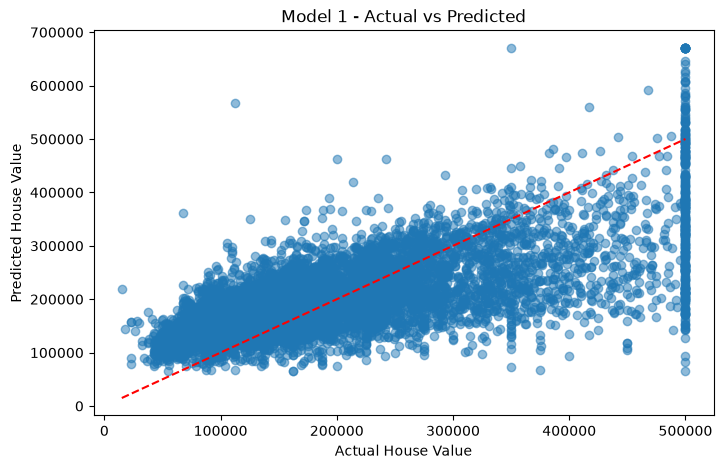

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y1_test, y1_pred, alpha=0.5)
plt.plot(
    [y1_test.min(), y1_test.max()],
    [y1_test.min(), y1_test.max()],
    'r--',
    label='Perfect line'
)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Model 1 - Actual vs Predicted")

plt.show()

# This is model 2

In [41]:
X2 = df[[
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "ocean_proximity_INLAND",
    "ocean_proximity_ISLAND",
    "ocean_proximity_NEAR BAY",
    "ocean_proximity_NEAR OCEAN"
]]

y2 = df["median_house_value"]

splitting data for testing and training

In [42]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.6,
    random_state=42
)

print("\nModel 2 Training Data:", X2_train.shape)
print("Model 2 Testing Data:", X2_test.shape)


Model 2 Training Data: (8256, 12)
Model 2 Testing Data: (12384, 12)


Training leanier regression model

In [43]:
# Create model
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("\nModel 2 trained!")


Model 2 trained!


Making predections

In [ ]:
y2_pred = model2.predict(X2_test)

In [47]:
# R2 Score
r2_2 = r2_score(y2_test, y2_pred)

print("\nModel 2 R2 Score:", r2_2)


Model 2 R2 Score: 0.6400694633580188


In [ ]:
# Compare actual vs predicted price
comparison2 = pd.DataFrame({
    "Actual": y2_test.values,
    "Predicted": y2_pred
})

print("\nModel 2 Actual vs Predicted:")
print(comparison2.head(10))



Model 2 Actual vs Predicted:
     Actual      Predicted
0   47700.0   69223.451468
1   45800.0  131234.270201
2  500001.0  254888.227646
3  218600.0  279717.941578
4  278000.0  270554.641379
5  158700.0  144400.332129
6  198200.0  306111.834582
7  157500.0  244144.906135
8  340000.0  265659.130601
9  446600.0  421212.881418


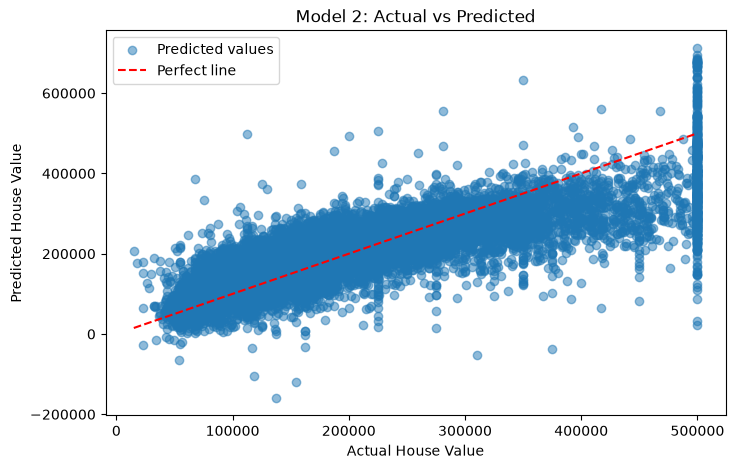

In [54]:
plt.figure(figsize=(8, 5))

plt.scatter(y2_test, y2_pred, alpha=0.5, label="Predicted values")
plt.plot(
    [y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    'r--',
    label='Perfect line'
)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Model 2: Actual vs Predicted")
plt.legend()

plt.show()

In [55]:
# COMparision

comparison = pd.DataFrame({
    "Model": [
        "Model 1 (median_income)",
        "Model 2 (All Features)"
    ],
    "Features Used": [
        "median_income",
        "longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, ocean_proximity"
    ],
    "R2 Score": [
        round(r2_1, 4),
        round(r2_2, 4)
    ]
})

print(comparison)

                     Model                                      Features Used  \
0  Model 1 (median_income)                                      median_income   
1   Model 2 (All Features)  longitude, latitude, housing_median_age, total...   

   R2 Score  
0    0.4589  
1    0.6401  


## Predecting house price

In [56]:
sample = pd.DataFrame({
    "longitude": [-122.23],
    "latitude": [37.88],
    "housing_median_age": [41],
    "total_rooms": [880],
    "total_bedrooms": [129],
    "population": [322],
    "households": [126],
    "median_income": [8.3],
    "ocean_proximity_INLAND": [False],
    "ocean_proximity_ISLAND": [False],
    "ocean_proximity_NEAR BAY": [True],
    "ocean_proximity_NEAR OCEAN": [False]
})
predicted_house_value = model2.predict(sample)[0]

print(f"Predicted House Value: ${predicted_house_value:.2f}")

Predicted House Value: $410319.40
